# Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import os

In [2]:
df = pd.read_csv("../data/processed/anime_data_1.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5338 entries, 0 to 5337
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mal_id        5338 non-null   int64  
 1   title         5338 non-null   str    
 2   source        5338 non-null   str    
 3   episodes      5338 non-null   float64
 4   synopsis      5338 non-null   str    
 5   year          5338 non-null   float64
 6   season        5338 non-null   str    
 7   producers     5338 non-null   str    
 8   genres        5338 non-null   str    
 9   studios       5338 non-null   str    
 10  demographics  5338 non-null   str    
 11  themes        5338 non-null   str    
 12  rating        5338 non-null   str    
 13  sequel        5338 non-null   bool   
 14  favorites     5338 non-null   int64  
 15  score         5338 non-null   float64
 16  wc            5338 non-null   int64  
 17  dropped       5338 non-null   int64  
 18  forum         5338 non-null   int64  
 

In [3]:
df = df.drop(columns=['type'])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5338 entries, 0 to 5337
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mal_id        5338 non-null   int64  
 1   title         5338 non-null   str    
 2   source        5338 non-null   str    
 3   episodes      5338 non-null   float64
 4   synopsis      5338 non-null   str    
 5   year          5338 non-null   float64
 6   season        5338 non-null   str    
 7   producers     5338 non-null   str    
 8   genres        5338 non-null   str    
 9   studios       5338 non-null   str    
 10  demographics  5338 non-null   str    
 11  themes        5338 non-null   str    
 12  rating        5338 non-null   str    
 13  sequel        5338 non-null   bool   
 14  favorites     5338 non-null   int64  
 15  score         5338 non-null   float64
 16  wc            5338 non-null   int64  
 17  dropped       5338 non-null   int64  
 18  forum         5338 non-null   int64  
d

## Univariate Analysis

### Sources

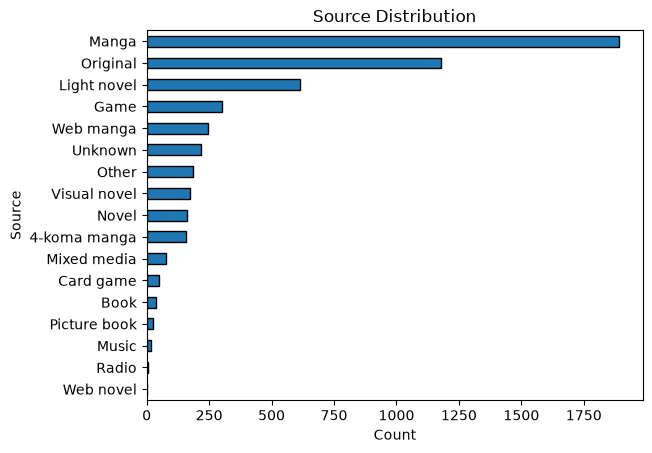

In [4]:
df['source'].value_counts(ascending=True).plot(kind='barh', edgecolor='black')
plt.title('Source Distribution')
plt.xlabel('Count')
plt.ylabel('Source')
plt.show()

### Episode Count

In [5]:
df['episodes'].describe()

count    5338.000000
mean       28.799363
std        70.972788
min         3.000000
25%        12.000000
50%        13.000000
75%        26.000000
max      1818.000000
Name: episodes, dtype: float64

Let's remove the outliers and visualize the rest via a histogram.

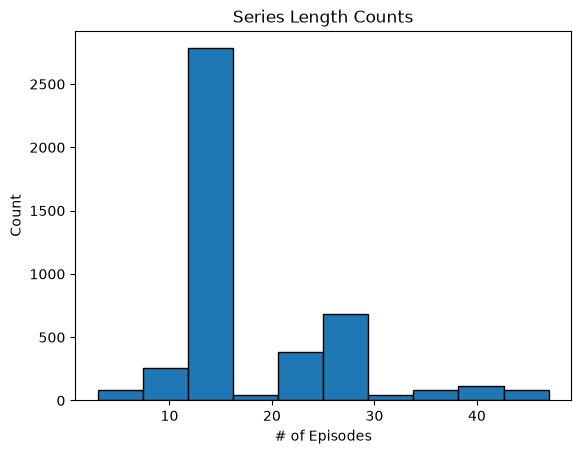

In [6]:
episode_counts = df['episodes']
q1 = episode_counts.quantile(0.25)
q3 = episode_counts.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

episode_counts_cleaned = [x for x in episode_counts if lower_bound <= x <= upper_bound]
plt.hist(episode_counts_cleaned, edgecolor='black')
plt.title('Series Length Counts')
plt.xlabel('# of Episodes')
plt.ylabel('Count')
plt.show()

### Year

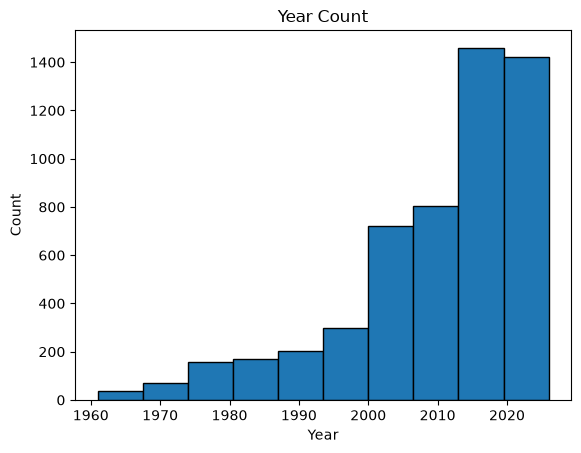

In [7]:
plt.hist(df['year'], edgecolor='black')
plt.title('Year Count')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

### Season

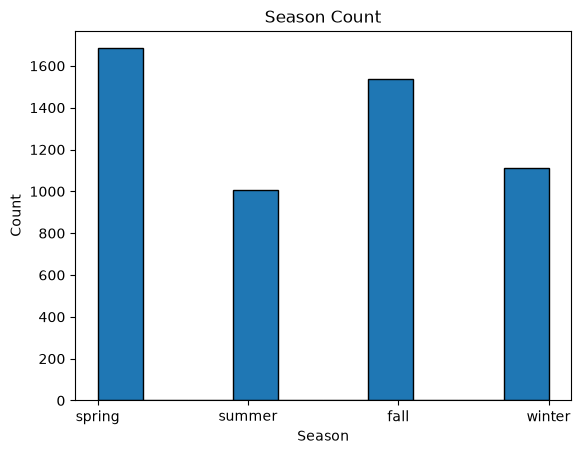

In [8]:
plt.hist(df['season'], edgecolor='black')
plt.title('Season Count')
plt.xlabel('Season')
plt.ylabel('Count')
plt.show()

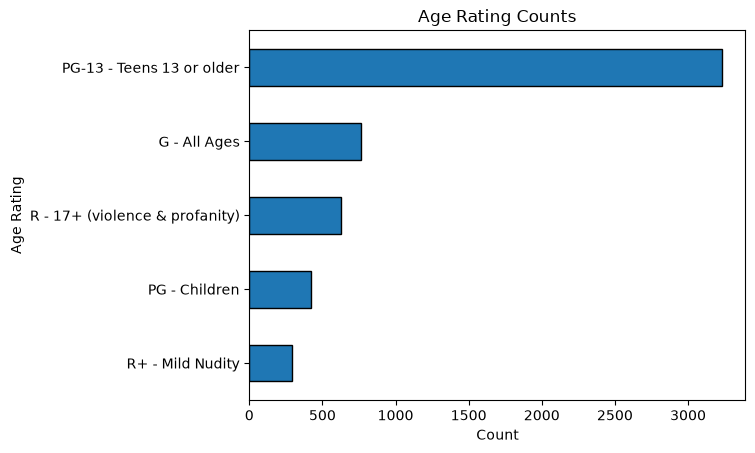

In [9]:
df['rating'].value_counts(ascending=True).plot(kind='barh', edgecolor='black')
plt.title('Age Rating Counts')
plt.xlabel('Count')
plt.ylabel('Age Rating')
plt.show()

### Score

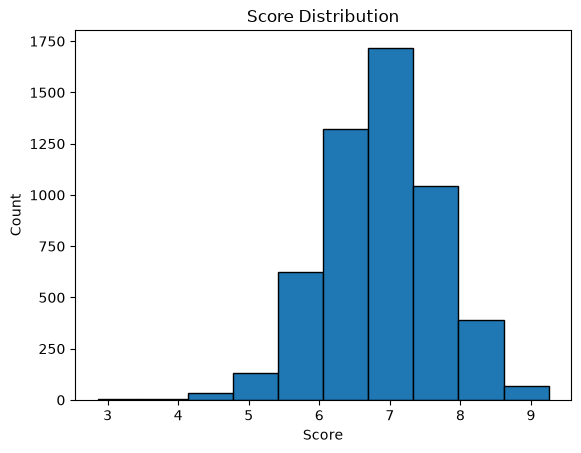

In [10]:
plt.hist(df['score'], edgecolor='black')
plt.title('Score Distribution')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

### Watching + Completed

In [11]:
df['wc'].describe()

count    5.338000e+03
mean     1.201037e+05
std      2.911425e+05
min      1.760000e+02
25%      2.946000e+03
50%      2.151300e+04
75%      9.939675e+04
max      4.095607e+06
Name: wc, dtype: float64

Let's remove outliers and visualize:

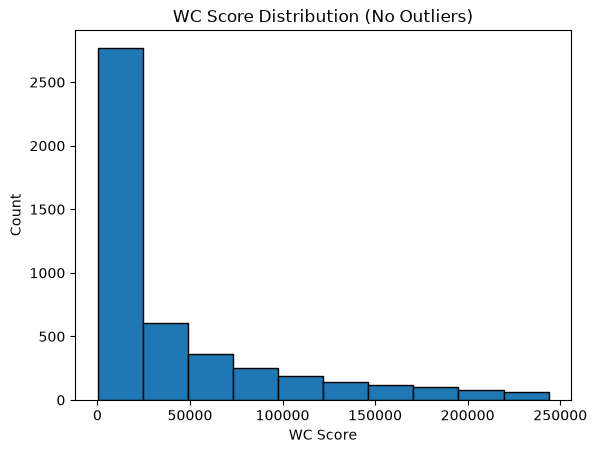

In [12]:
wc_counts = df['wc']
q1 = wc_counts.quantile(0.25)
q3 = wc_counts.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

wc_counts_cleaned = [x for x in wc_counts if lower_bound <= x <= upper_bound]

plt.hist(wc_counts_cleaned, edgecolor='black')
plt.title('WC Score Distribution (No Outliers)')
plt.xlabel('WC Score')
plt.ylabel('Count')
plt.show()

### Dropped

In [13]:
df['dropped'].describe()

count      5338.000000
mean       6668.592919
std       12676.125411
min          61.000000
25%         399.000000
50%        2096.000000
75%        7875.500000
max      247257.000000
Name: dropped, dtype: float64

Remove outliers and visualize:

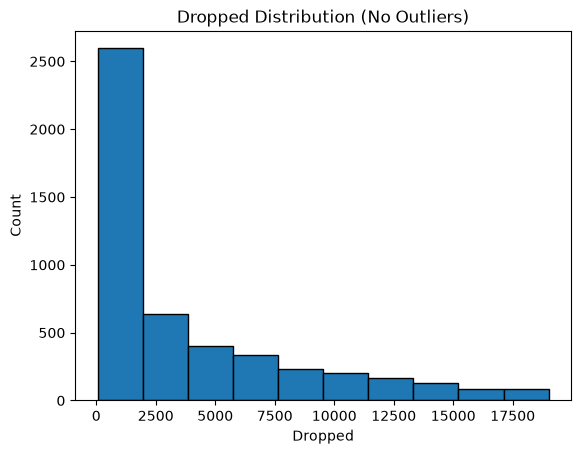

In [14]:
dropped_counts = df['dropped']
q1 = dropped_counts.quantile(0.25)
q3 = dropped_counts.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

dropped_counts_cleaned = [x for x in dropped_counts if lower_bound <= x <= upper_bound]

plt.hist(dropped_counts_cleaned, edgecolor='black')
plt.title('Dropped Distribution (No Outliers)')
plt.xlabel('Dropped')
plt.ylabel('Count')
plt.show()

### Favorites

In [15]:
df['favorites'].describe()

count      5338.000000
mean       2088.663357
std        9900.235234
min           0.000000
25%          13.000000
50%         117.000000
75%         729.750000
max      244924.000000
Name: favorites, dtype: float64

Remove outliers and visualize:

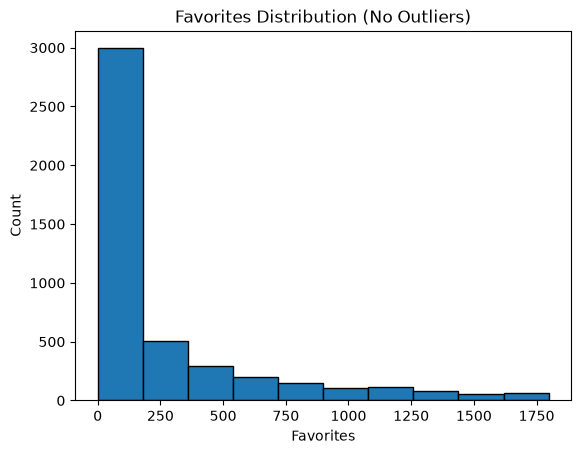

In [16]:
fav_counts = df['favorites']
q1 = fav_counts.quantile(0.25)
q3 = fav_counts.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

fav_counts_cleaned = [x for x in fav_counts if lower_bound <= x <= upper_bound]

plt.hist(fav_counts_cleaned, edgecolor='black')
plt.title('Favorites Distribution (No Outliers)')
plt.xlabel('Favorites')
plt.ylabel('Count')
plt.show()

### Forum Posts

In [17]:
df['forum'].describe()

count     5338.000000
mean       630.828025
std       1033.267525
min          0.000000
25%          9.000000
50%        243.000000
75%        851.750000
max      16318.000000
Name: forum, dtype: float64

Remove outliers and visualize:

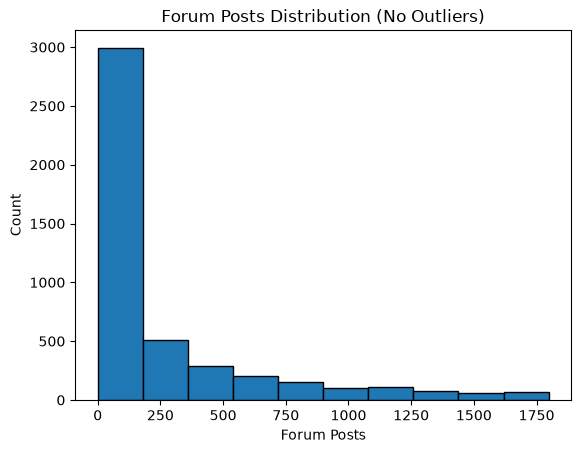

In [18]:
forum_counts = df['forum']
q1 = forum_counts.quantile(0.25)
q3 = forum_counts.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

forum_counts_cleaned = [x for x in forum_counts if lower_bound <= x <= upper_bound]

plt.hist(fav_counts_cleaned, edgecolor='black')
plt.title('Forum Posts Distribution (No Outliers)')
plt.xlabel('Forum Posts')
plt.ylabel('Count')
plt.show()

There seems to be an emerging pattern in the metrics distribution, which is somewhat to be expected: it's normal to see bigger shows have proportionally bigger counts for specific metrics such as favorites, wc score, forum posts, etc.

Other features such as producers, genres, demographics, and themes will be feature-engineered and visualize in the next notebook.

## Bivariate

We will primarily be interested with scores, and including other metrics at the end will be decided soon.

### Yearly Score Averages

In [19]:
yearly_score = df.groupby(df['year'])['score'].mean()
yearly_score

year
1961.0    6.100000
1962.0    6.000000
1963.0    6.450000
1964.0    6.245000
1965.0    6.110000
            ...   
2022.0    6.954560
2023.0    7.034771
2024.0    7.033783
2025.0    6.952051
2026.0    7.108400
Name: score, Length: 66, dtype: float64

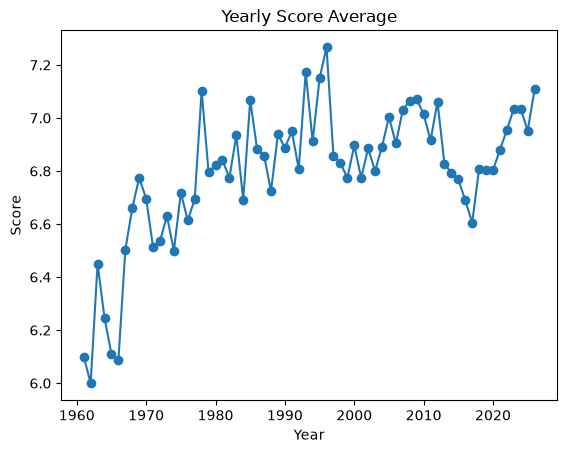

In [20]:
yearly_score.plot(kind='line', marker='o')

plt.title("Yearly Score Average")
plt.xlabel("Year")
plt.ylabel("Score")
plt.grid=True

plt.show()

### Season Score Averages

In [21]:
season_score = df.groupby(df['season'])['score'].mean()
season_score

season
fall      6.917866
spring    6.890089
summer    6.855592
winter    6.841024
Name: score, dtype: float64

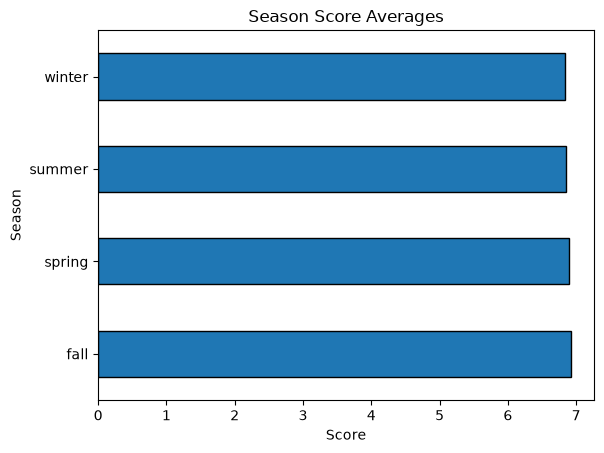

In [22]:
season_score.plot(kind='barh', edgecolor='black')
plt.title('Season Score Averages')
plt.xlabel('Score')
plt.ylabel('Season')
plt.show()

### Age Rating Averages

In [23]:
rating_score = df.groupby(df['rating'])['score'].mean()
rating_score

rating
G - All Ages                      6.554016
PG - Children                     6.486841
PG-13 - Teens 13 or older         6.949115
R - 17+ (violence & profanity)    7.301709
R+ - Mild Nudity                  6.660918
Name: score, dtype: float64

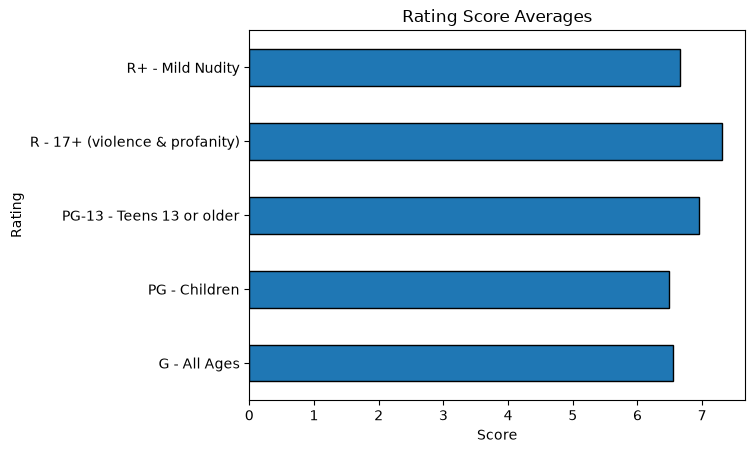

In [24]:
rating_score.plot(kind='barh', edgecolor='black')
plt.title('Rating Score Averages')
plt.xlabel('Score')
plt.ylabel('Rating')
plt.show()

### Sequel vs. Non-sequel

In [25]:
sequel_score = df.groupby(df['sequel'])['score'].mean()
sequel_score

sequel
False    6.799642
True     7.111674
Name: score, dtype: float64

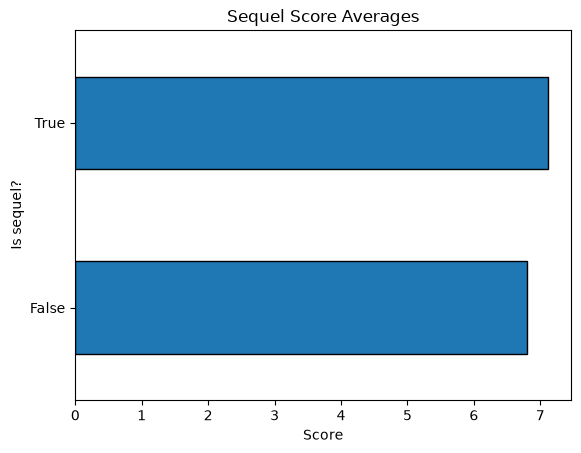

In [26]:
sequel_score.plot(kind='barh', edgecolor='black')
plt.title('Sequel Score Averages')
plt.xlabel('Score')
plt.ylabel('Is sequel?')
plt.show()

### Score vs. WC Scatterplot

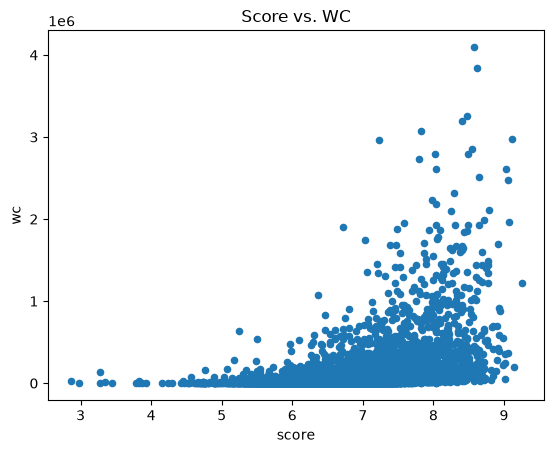

In [27]:
df.plot.scatter(x='score', y='wc', title="Score vs. WC")
plt.show()

### Scores vs. Favorites Scatterplot

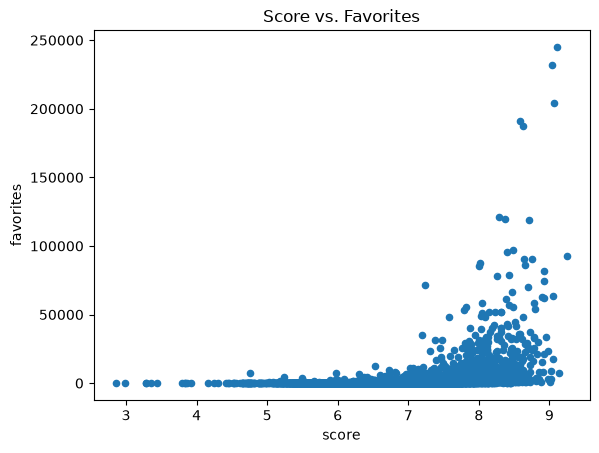

In [28]:
df.plot.scatter(x='score', y='favorites', title="Score vs. Favorites")
plt.show()

### Scores vs. Dropped Scatterplot

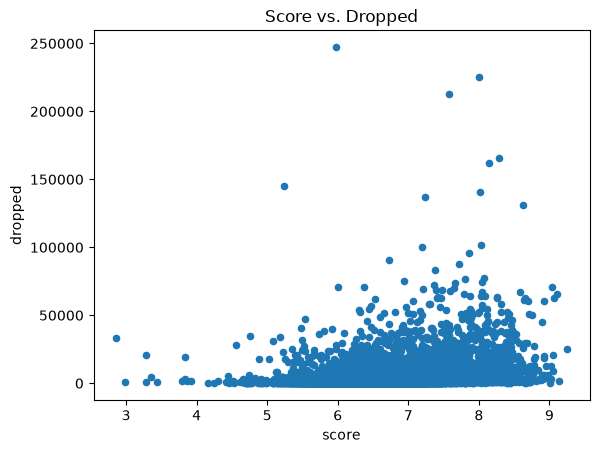

In [29]:
df.plot.scatter(x='score', y='dropped', title="Score vs. Dropped")
plt.show()

### Score vs. Forum Posts

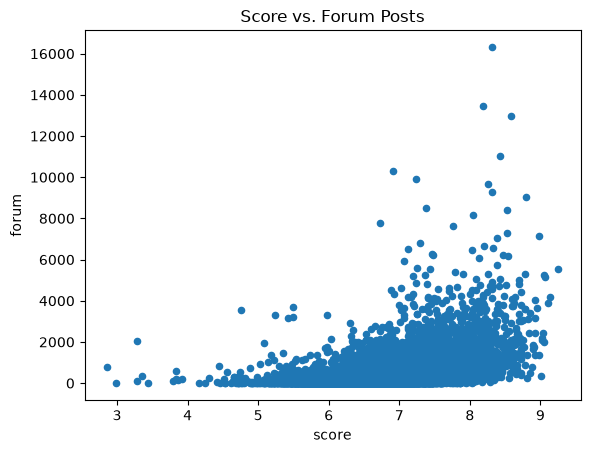

In [30]:
df.plot.scatter(x='score', y='forum', title="Score vs. Forum Posts")
plt.show()

In [31]:
folder_path = "../data/processed"
file_name = "anime_data_1.csv"
full_path = os.path.join(folder_path, file_name)
df.to_csv(full_path, index=False)
print(f"File successfully saved to: {full_path}")

File successfully saved to: ../data/processed\anime_data_1.csv
